[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



DATASET LOADED
Shape: (10000, 4)

Columns found in CSV:
['complaint_id', 'category', 'sub_category', 'description']

First 5 rows:
   complaint_id                               category  \
0        100001             Hacking/Damage to Computer   
1        100002                 Online Financial Fraud   
2        100003                 Online Financial Fraud   
3        100004  Online and Social Media Related Crime   
4        100005                   Cryptocurrency Crime   

                      sub_category  \
0                    Email Hacking   
1               UPI Related Frauds   
2               Fraud Call/Vishing   
3  Cyber Bullying/Stalking/Sexting   
4             Cryptocurrency Fraud   

                                         description  
0  The complainant's email account was hacked and...  
1  Money amounting to Rs. 3,20,000 was debited fr...  
2  The complainant received a call about a fake l...  
3  The complainant reported being repeatedly hara...  
4  The complain

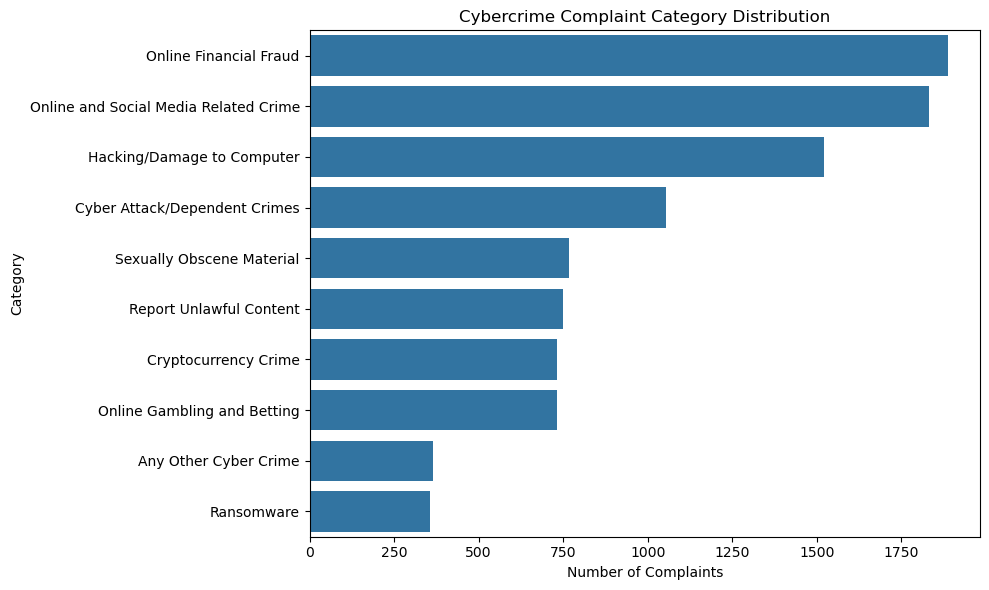


TEXT STATISTICS
        text_length    word_count    char_count
count  10000.000000  10000.000000  10000.000000
mean     124.285100     18.190100    124.285100
std       19.401728      3.267175     19.401728
min       90.000000     13.000000     90.000000
25%      112.000000     16.000000    112.000000
50%      125.000000     18.000000    125.000000
75%      132.000000     20.000000    132.000000
max      198.000000     29.000000    198.000000


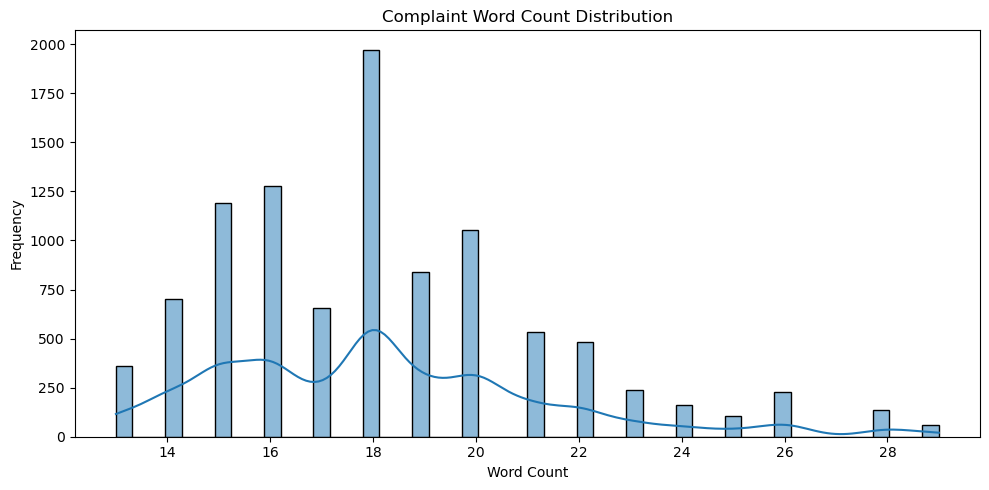


CLEANING TEXT

Original:
The complainant's email account was hacked and the password changed, locking them out of access.

Cleaned:
complainant email account hacked password changed locking access

FEATURE ENGINEERING
   text_length  word_count  url_count  number_count  special_char_count  \
0           96          15          0             0                   3   
1          146          22          0             3                   5   
2           91          16          0             2                   3   
3           98          14          0             0                   1   
4          127          21          0             2                   3   

   keyword_count  
0              4  
1              2  
2              2  
3              2  
4              0  

TRAIN TEST SPLIT
Training samples: 8000
Testing samples: 2000

TF-IDF
TF-IDF shape: (8000, 1014)

Final feature shape:
(8000, 1020)

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

C

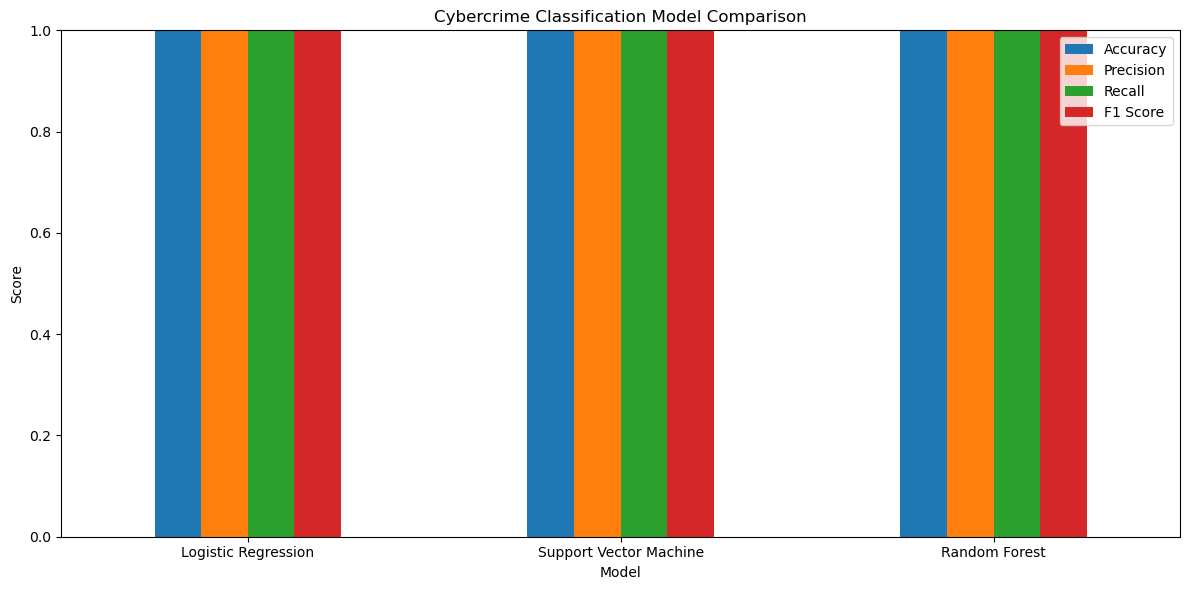

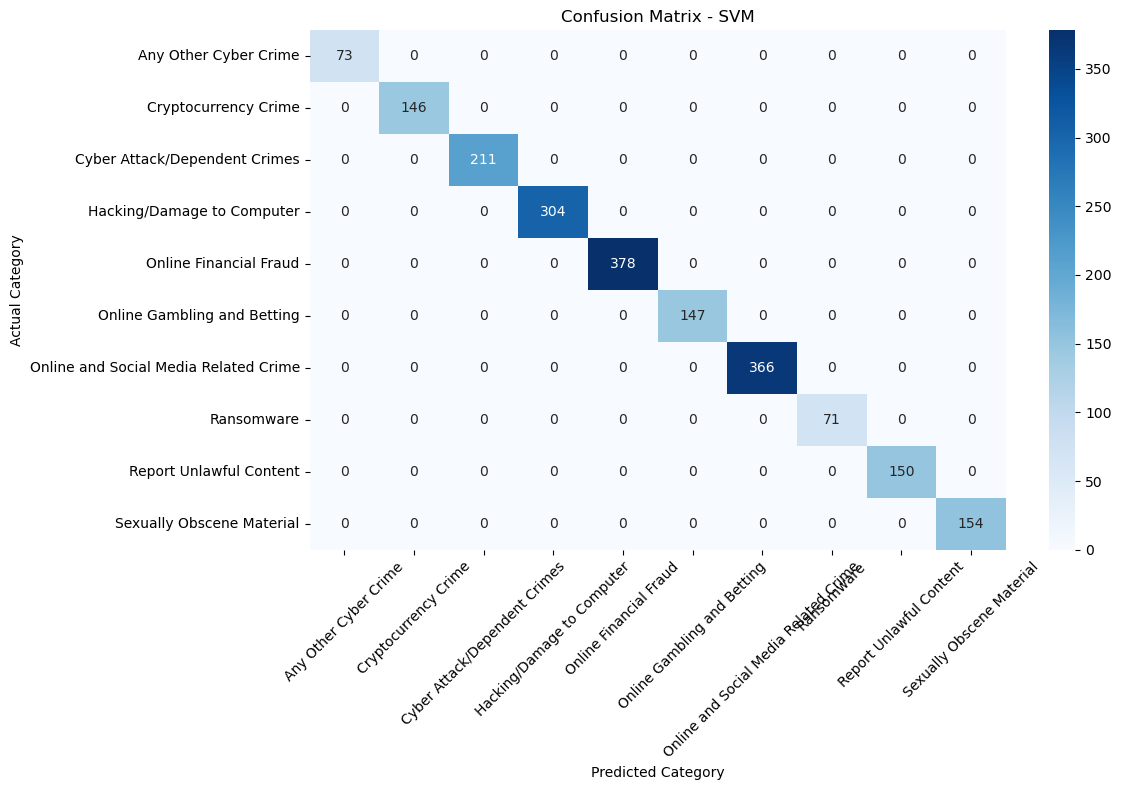


CROSS VALIDATION
CV Scores: [1. 1. 1. 1. 1.]
Mean CV F1: 1.0

HYPERPARAMETER TUNING
Best Parameters: {'C': 0.1}
Best CV F1: 1.0

FINAL MODEL PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
                                       precision    recall  f1-score   support

                Any Other Cyber Crime       1.00      1.00      1.00        73
                 Cryptocurrency Crime       1.00      1.00      1.00       146
        Cyber Attack/Dependent Crimes       1.00      1.00      1.00       211
           Hacking/Damage to Computer       1.00      1.00      1.00       304
               Online Financial Fraud       1.00      1.00      1.00       378
          Online Gambling and Betting       1.00      1.00      1.00       147
Online and Social Media Related Crime       1.00      1.00      1.00       366
                           Ransomware       1.00      1.00      1.00        71
              Report Unlawful Content       1.00  

In [1]:

# ============================================================
# CYBERCRIME COMPLAINT CATEGORY CLASSIFICATION USING NLP
# ============================================================

# Install:
# pip install pandas numpy matplotlib seaborn scikit-learn nltk xgboost joblib scipy gradio


import pandas as pd
import numpy as np
import re
import string
import joblib
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# IMPORTS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier


# ============================================================
# 1. NLTK DATA
# ============================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


# ============================================================
# 2. LOAD DATASET
# ============================================================

FILE = "cybercrime_complaints_10k (1).csv"

df = pd.read_csv(FILE)

print("\n============================================")
print("DATASET LOADED")
print("============================================")

print("Shape:", df.shape)

print("\nColumns found in CSV:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned column names:")
print(df.columns.tolist())


# ============================================================
# 4. AUTOMATICALLY FIND TEXT COLUMN
# ============================================================

possible_text_columns = [
    "complaint_text",
    "complaint",
    "text",
    "description",
    "complaint_description",
    "message",
    "content"
]

TEXT_COLUMN = None

for column in possible_text_columns:

    if column in df.columns:
        TEXT_COLUMN = column
        break


# ============================================================
# 5. AUTOMATICALLY FIND TARGET COLUMN
# ============================================================

possible_target_columns = [
    "category",
    "label",
    "class",
    "target",
    "crime_category",
    "crime_type",
    "complaint_category",
    "type"
]

TARGET_COLUMN = None

for column in possible_target_columns:

    if column in df.columns:
        TARGET_COLUMN = column
        break


# ============================================================
# 6. DISPLAY DETECTED COLUMNS
# ============================================================

print("\n============================================")
print("COLUMN DETECTION")
print("============================================")

print("Text column  :", TEXT_COLUMN)
print("Target column:", TARGET_COLUMN)


# ============================================================
# 7. IF COLUMN NOT FOUND
# ============================================================

if TEXT_COLUMN is None:

    print("\nERROR: Complaint text column was not found.")

    print("\nAvailable columns:")
    for column in df.columns:
        print("-", column)

    raise ValueError(
        "\nPlease change TEXT_COLUMN manually "
        "to the column containing complaint text."
    )


if TARGET_COLUMN is None:

    print("\nERROR: Category/label column was not found.")

    print("\nAvailable columns:")
    for column in df.columns:
        print("-", column)

    raise ValueError(
        "\nPlease change TARGET_COLUMN manually "
        "to the column containing category labels."
    )


# ============================================================
# 8. CHECK DATA
# ============================================================

print("\n============================================")
print("MISSING VALUES")
print("============================================")

print(df.isnull().sum())


print("\nDuplicate rows:", df.duplicated().sum())


# ============================================================
# 9. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 10. REMOVE MISSING VALUES
# ============================================================

df = df.dropna(
    subset=[
        TEXT_COLUMN,
        TARGET_COLUMN
    ]
)

print("\nShape after removing missing values:")
print(df.shape)


# ============================================================
# 11. CONVERT TO STRING
# ============================================================

df[TEXT_COLUMN] = df[
    TEXT_COLUMN
].astype(str)

df[TARGET_COLUMN] = df[
    TARGET_COLUMN
].astype(str)


# ============================================================
# 12. CATEGORY DISTRIBUTION
# ============================================================

print("\n============================================")
print("CATEGORY DISTRIBUTION")
print("============================================")

print(
    df[TARGET_COLUMN].value_counts()
)


# ============================================================
# 13. CATEGORY VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y=TARGET_COLUMN,
    order=df[
        TARGET_COLUMN
    ].value_counts().index
)

plt.title(
    "Cybercrime Complaint Category Distribution"
)

plt.xlabel("Number of Complaints")

plt.ylabel("Category")

plt.tight_layout()

plt.show()


# ============================================================
# 14. TEXT STATISTICS
# ============================================================

df["text_length"] = df[
    TEXT_COLUMN
].apply(len)

df["word_count"] = df[
    TEXT_COLUMN
].apply(
    lambda x: len(x.split())
)

df["char_count"] = df[
    TEXT_COLUMN
].apply(len)


print("\n============================================")
print("TEXT STATISTICS")
print("============================================")

print(
    df[
        [
            "text_length",
            "word_count",
            "char_count"
        ]
    ].describe()
)


# ============================================================
# 15. WORD COUNT VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True
)

plt.title(
    "Complaint Word Count Distribution"
)

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()


# ============================================================
# 16. NLP PREPROCESSING
# ============================================================

stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()


def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove email
    text = re.sub(
        r"\S+@\S+",
        "",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # Tokenization
    words = text.split()

    # Stopword removal
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)


print("\n============================================")
print("CLEANING TEXT")
print("============================================")

df["cleaned_text"] = df[
    TEXT_COLUMN
].apply(clean_text)


print("\nOriginal:")
print(df[TEXT_COLUMN].iloc[0])

print("\nCleaned:")
print(df["cleaned_text"].iloc[0])


# ============================================================
# 17. EXTRA FEATURE ENGINEERING
# ============================================================

def count_urls(text):

    return len(
        re.findall(
            r"http\S+|www\S+|https\S+",
            text
        )
    )


def count_numbers(text):

    return len(
        re.findall(
            r"\d+",
            text
        )
    )


def count_special_characters(text):

    return len(
        re.findall(
            r"[^a-zA-Z0-9\s]",
            text
        )
    )


def count_keywords(text):

    keywords = [
        "otp",
        "bank",
        "password",
        "hacked",
        "fraud",
        "scam",
        "money",
        "account",
        "instagram",
        "facebook",
        "email",
        "threat",
        "blackmail",
        "phishing",
        "fake"
    ]

    text = text.lower()

    return sum(
        1
        for keyword in keywords
        if keyword in text
    )


df["url_count"] = df[
    TEXT_COLUMN
].apply(count_urls)

df["number_count"] = df[
    TEXT_COLUMN
].apply(count_numbers)

df["special_char_count"] = df[
    TEXT_COLUMN
].apply(
    count_special_characters
)

df["keyword_count"] = df[
    TEXT_COLUMN
].apply(count_keywords)


# ============================================================
# 18. SHOW ENGINEERED FEATURES
# ============================================================

print("\n============================================")
print("FEATURE ENGINEERING")
print("============================================")

print(
    df[
        [
            "text_length",
            "word_count",
            "url_count",
            "number_count",
            "special_char_count",
            "keyword_count"
        ]
    ].head()
)


# ============================================================
# 19. INPUT AND TARGET
# ============================================================

X_text = df[
    "cleaned_text"
]

X_extra = df[
    [
        "text_length",
        "word_count",
        "url_count",
        "number_count",
        "special_char_count",
        "keyword_count"
    ]
]

y = df[
    TARGET_COLUMN
]


# ============================================================
# 20. TRAIN TEST SPLIT
# ============================================================

(
    X_text_train,
    X_text_test,
    X_extra_train,
    X_extra_test,
    y_train,
    y_test
) = train_test_split(

    X_text,
    X_extra,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n============================================")
print("TRAIN TEST SPLIT")
print("============================================")

print(
    "Training samples:",
    len(X_text_train)
)

print(
    "Testing samples:",
    len(X_text_test)
)


# ============================================================
# 21. TF-IDF
# ============================================================

tfidf = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True
)


X_train_tfidf = tfidf.fit_transform(
    X_text_train
)

X_test_tfidf = tfidf.transform(
    X_text_test
)


print("\n============================================")
print("TF-IDF")
print("============================================")

print(
    "TF-IDF shape:",
    X_train_tfidf.shape
)


# ============================================================
# 22. SCALE EXTRA FEATURES
# ============================================================

scaler = StandardScaler()

X_extra_train_scaled = scaler.fit_transform(
    X_extra_train
)

X_extra_test_scaled = scaler.transform(
    X_extra_test
)


X_extra_train_sparse = csr_matrix(
    X_extra_train_scaled
)

X_extra_test_sparse = csr_matrix(
    X_extra_test_scaled
)


# ============================================================
# 23. COMBINE FEATURES
# ============================================================

X_train_final = hstack(
    [
        X_train_tfidf,
        X_extra_train_sparse
    ]
)

X_test_final = hstack(
    [
        X_test_tfidf,
        X_extra_test_sparse
    ]
)


print("\nFinal feature shape:")
print(X_train_final.shape)


# ============================================================
# 24. MODEL EVALUATION FUNCTION
# ============================================================

results = []


def evaluate_model(
    model,
    model_name
):

    print("\n============================================")
    print(model_name)
    print("============================================")

    model.fit(
        X_train_final,
        y_train
    )

    predictions = model.predict(
        X_test_final
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    print(
        "Accuracy :",
        round(accuracy, 4)
    )

    print(
        "Precision:",
        round(precision, 4)
    )

    print(
        "Recall   :",
        round(recall, 4)
    )

    print(
        "F1 Score :",
        round(f1, 4)
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        }
    )

    return model


# ============================================================
# 25. LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(

    max_iter=2000,

    class_weight="balanced"
)


logistic_model = evaluate_model(

    logistic_model,

    "Logistic Regression"
)


# ============================================================
# 26. SVM
# ============================================================

svm_model = LinearSVC(

    C=1.0,

    class_weight="balanced"
)


svm_model = evaluate_model(

    svm_model,

    "Support Vector Machine"
)


# ============================================================
# 27. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1
)


rf_model = evaluate_model(

    rf_model,

    "Random Forest"
)


# ============================================================
# 28. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n============================================")
print("MODEL COMPARISON")
print("============================================")

print(results_df)


# ============================================================
# 29. PERFORMANCE GRAPH
# ============================================================

results_plot = results_df.set_index(
    "Model"
)


results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)


plt.title(
    "Cybercrime Classification Model Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()


# ============================================================
# 30. CONFUSION MATRIX
# ============================================================

svm_predictions = svm_model.predict(
    X_test_final
)


labels = sorted(
    y.unique()
)


cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=labels
)


plt.figure(figsize=(12, 8))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)


plt.title(
    "Confusion Matrix - SVM"
)

plt.xlabel(
    "Predicted Category"
)

plt.ylabel(
    "Actual Category"
)

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


# ============================================================
# 31. CROSS VALIDATION
# ============================================================

print("\n============================================")
print("CROSS VALIDATION")
print("============================================")


cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


cv_scores = cross_val_score(

    LinearSVC(
        C=1.0,
        class_weight="balanced"
    ),

    X_train_final,

    y_train,

    cv=cv,

    scoring="f1_weighted",

    n_jobs=-1
)


print(
    "CV Scores:",
    cv_scores
)

print(
    "Mean CV F1:",
    round(
        cv_scores.mean(),
        4
    )
)


# ============================================================
# 32. HYPERPARAMETER TUNING
# ============================================================

print("\n============================================")
print("HYPERPARAMETER TUNING")
print("============================================")


param_grid = {

    "C": [
        0.1,
        0.5,
        1,
        2,
        5
    ]

}


grid_search = GridSearchCV(

    LinearSVC(
        class_weight="balanced"
    ),

    param_grid,

    cv=5,

    scoring="f1_weighted",

    n_jobs=-1
)


grid_search.fit(

    X_train_final,

    y_train
)


print(
    "Best Parameters:",
    grid_search.best_params_
)


print(
    "Best CV F1:",
    grid_search.best_score_
)


# ============================================================
# 33. FINAL MODEL
# ============================================================

final_model = grid_search.best_estimator_


final_predictions = final_model.predict(
    X_test_final
)


print("\n============================================")
print("FINAL MODEL PERFORMANCE")
print("============================================")


final_accuracy = accuracy_score(
    y_test,
    final_predictions
)


final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)


final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)


final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)


print(
    "Accuracy :",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall   :",
    round(final_recall, 4)
)

print(
    "F1 Score :",
    round(final_f1, 4)
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)


# ============================================================
# 34. SAVE MODEL
# ============================================================

joblib.dump(
    final_model,
    "cybercrime_classifier.pkl"
)


joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)


joblib.dump(
    scaler,
    "feature_scaler.pkl"
)


print("\n============================================")
print("MODEL SAVED")
print("============================================")

print(
    "cybercrime_classifier.pkl"
)

print(
    "tfidf_vectorizer.pkl"
)

print(
    "feature_scaler.pkl"
)


# ============================================================
# 35. PREDICTION FUNCTION
# ============================================================

def predict_category(
    complaint
):

    cleaned = clean_text(
        complaint
    )


    # TF-IDF
    text_vector = tfidf.transform(
        [cleaned]
    )


    # Extra features
    extra = np.array(
        [
            [
                len(complaint),

                len(
                    complaint.split()
                ),

                count_urls(
                    complaint
                ),

                count_numbers(
                    complaint
                ),

                count_special_characters(
                    complaint
                ),

                count_keywords(
                    complaint
                )
            ]
        ]
    )


    # Scale
    extra_scaled = scaler.transform(
        extra
    )


    extra_sparse = csr_matrix(
        extra_scaled
    )


    # Combine
    final_input = hstack(
        [
            text_vector,
            extra_sparse
        ]
    )


    # Prediction
    prediction = final_model.predict(
        final_input
    )[0]


    return prediction


# ============================================================
# 36. TEST PREDICTION
# ============================================================

test_complaint = (
    "Someone created a fake Instagram account "
    "using my photos and is messaging my friends."
)


prediction = predict_category(
    test_complaint
)


print("\n============================================")
print("TEST PREDICTION")
print("============================================")


print(
    "Complaint:"
)

print(
    test_complaint
)


print(
    "\nPredicted Category:"
)

print(
    prediction
)





In [2]:
 # ============================================================
# 37. GRADIO DEPLOYMENT  (replace your old section 37 with this)
# ============================================================

import html
import gradio as gr


# ------------------------------------------------------------
# PREDICTION HELPER (returns category + confidence for top 3)
# ------------------------------------------------------------

def predict_with_scores(complaint):

    cleaned = clean_text(complaint)

    text_vector = tfidf.transform([cleaned])

    extra = np.array([[
        len(complaint),
        len(complaint.split()),
        count_urls(complaint),
        count_numbers(complaint),
        count_special_characters(complaint),
        count_keywords(complaint)
    ]])

    extra_sparse = csr_matrix(scaler.transform(extra))

    final_input = hstack([text_vector, extra_sparse])

    classes = final_model.classes_

    # LinearSVC has no predict_proba, so turn its decision scores
    # into a relative confidence with a softmax.
    if hasattr(final_model, "predict_proba"):
        probs = final_model.predict_proba(final_input)[0]
    else:
        scores = final_model.decision_function(final_input)

        if scores.ndim == 1:                      # binary case
            scores = np.array([-scores[0], scores[0]])
        else:
            scores = scores[0]

        exp_scores = np.exp(scores - scores.max())
        probs = exp_scores / exp_scores.sum()

    top_idx = np.argsort(probs)[::-1][:3]

    top_labels = {str(classes[i]): float(probs[i]) for i in top_idx}

    best_label = str(classes[top_idx[0]])
    best_conf = float(probs[top_idx[0]])

    return best_label, best_conf, top_labels


# ------------------------------------------------------------
# HTML BLOCKS
# ------------------------------------------------------------

HERO_HTML = """
<div class="hero">
  <div class="hero-badge">Cyber cell complaint desk</div>
  <h1>Cybercrime Complaint Classifier</h1>
  <p>Describe what happened in your own words. The model reads the
     complaint and tells you which type of cybercrime it is.</p>
</div>
"""

EMPTY_RESULT_HTML = """
<div class="result-card empty">
  <div class="result-title">No result yet</div>
  <div class="result-hint">Write a complaint on the left, then choose
  <b>Classify complaint</b>.</div>
</div>
"""

STEPS_HTML = """
<div class="steps">
  <div class="step"><span class="step-no">1</span><b>Clean</b><small>lowercase, remove links, stop words</small></div>
  <div class="step"><span class="step-no">2</span><b>Vectorise</b><small>TF-IDF word and phrase weights</small></div>
  <div class="step"><span class="step-no">3</span><b>Add signals</b><small>length, links, numbers, keywords</small></div>
  <div class="step"><span class="step-no">4</span><b>Classify</b><small>tuned linear SVM picks the category</small></div>
</div>
"""


def result_html(label, confidence):

    pct = round(confidence * 100, 1)

    if confidence >= 0.70:
        level, note = "high", "High confidence"
    elif confidence >= 0.40:
        level, note = "medium", "Medium confidence"
    else:
        level, note = "low", "Low confidence. Please review this complaint manually."

    return f"""
    <div class="result-card {level}">
      <div class="result-kicker">Predicted category</div>
      <div class="result-title">{html.escape(label)}</div>
      <div class="meter"><div class="meter-fill" style="width:{pct}%"></div></div>
      <div class="result-meta"><b>{pct}%</b> match score &nbsp;|&nbsp; {note}</div>
    </div>
    """


# ------------------------------------------------------------
# GRADIO PREDICTION FUNCTION
# ------------------------------------------------------------

def gradio_predict(complaint):

    if complaint is None or complaint.strip() == "":
        warning = """
        <div class="result-card low">
          <div class="result-title">Nothing to classify</div>
          <div class="result-hint">Please type or paste a complaint first.</div>
        </div>
        """
        return warning, None

    label, confidence, top_labels = predict_with_scores(complaint)

    return result_html(label, confidence), top_labels


def clear_all():
    return "", EMPTY_RESULT_HTML, None


# ------------------------------------------------------------
# STYLE
# ------------------------------------------------------------

theme = gr.themes.Soft(
    primary_hue="teal",
    secondary_hue="slate",
    neutral_hue="slate",
    font=[
        gr.themes.GoogleFont("IBM Plex Sans"),
        "system-ui",
        "sans-serif"
    ],
    radius_size="md"
)

CUSTOM_CSS = """
.gradio-container { max-width: 1080px !important; margin: auto !important; }
footer { display: none !important; }

/* Header */
.hero {
  background: #12263f;
  color: #ffffff;
  border-radius: 14px;
  padding: 34px 36px;
  margin-bottom: 8px;
}
.hero h1 { margin: 10px 0 8px; font-size: 2rem; font-weight: 700; color: #ffffff; }
.hero p  { margin: 0; max-width: 620px; line-height: 1.6; color: #cbd8e6; }
.hero-badge {
  display: inline-block;
  background: #1f8a7d;
  color: #ffffff;
  padding: 4px 12px;
  border-radius: 999px;
  font-size: 0.8rem;
  font-weight: 600;
}

/* Result card (works in light and dark mode) */
.result-card {
  background: var(--background-fill-secondary);
  color: var(--body-text-color);
  border: 1px solid var(--border-color-primary);
  border-left: 6px solid #1f8a7d;
  border-radius: 12px;
  padding: 20px 22px;
  min-height: 150px;
}
.result-card.medium { border-left-color: #d99a1e; }
.result-card.low    { border-left-color: #c8553d; }
.result-card.empty  { border-left-color: var(--border-color-primary); }
.result-kicker { font-size: 0.85rem; opacity: 0.7; margin-bottom: 4px; }
.result-title  { font-size: 1.6rem; font-weight: 700; line-height: 1.25; }
.result-hint   { margin-top: 8px; opacity: 0.75; }
.result-meta   { margin-top: 10px; font-size: 0.92rem; opacity: 0.85; }
.meter { height: 10px; background: var(--border-color-primary); border-radius: 999px; margin-top: 14px; overflow: hidden; }
.meter-fill { height: 100%; background: #1f8a7d; border-radius: 999px; transition: width 0.5s ease; }
.result-card.medium .meter-fill { background: #d99a1e; }
.result-card.low .meter-fill    { background: #c8553d; }

/* Pipeline steps */
.steps { display: grid; grid-template-columns: repeat(auto-fit, minmax(210px, 1fr)); gap: 12px; margin-top: 6px; }
.step {
  background: var(--background-fill-secondary);
  border: 1px solid var(--border-color-primary);
  border-radius: 12px;
  padding: 14px 16px;
  display: grid;
  gap: 4px;
}
.step small { opacity: 0.75; }
.step-no {
  width: 26px; height: 26px; border-radius: 50%;
  background: #12263f; color: #fff;
  display: inline-flex; align-items: center; justify-content: center;
  font-size: 0.8rem; font-weight: 700;
}

@media (prefers-reduced-motion: reduce) {
  .meter-fill { transition: none; }
}
"""


# ------------------------------------------------------------
# GRADIO UI
# ------------------------------------------------------------

with gr.Blocks(
    title="Cybercrime Complaint Classifier",
    theme=theme,
    css=CUSTOM_CSS
) as demo:

    gr.HTML(HERO_HTML)

    with gr.Row(equal_height=False):

        # Left: input
        with gr.Column(scale=3):

            complaint_input = gr.Textbox(
                label="Your complaint",
                placeholder=(
                    "Example: Someone created a fake Instagram account "
                    "using my photos and is messaging my friends."
                ),
                lines=9,
                max_lines=14
            )

            with gr.Row():
                predict_button = gr.Button(
                    "Classify complaint",
                    variant="primary",
                    scale=3
                )
                clear_button = gr.Button(
                    "Clear",
                    variant="secondary",
                    scale=1
                )

        # Right: result
        with gr.Column(scale=2):

            result_output = gr.HTML(EMPTY_RESULT_HTML)

            top_output = gr.Label(
                label="Top 3 possible categories",
                num_top_classes=3
            )

    gr.Examples(
        label="Try a complaint example",
        examples=[
            # 1. Phishing
            ["I received a fake email asking me to click a link and enter my banking details."],

            # 2. Online Banking Fraud
            ["Someone accessed my bank account online and transferred money without my permission."],

            # 3. UPI Fraud
            ["I was tricked into approving a UPI payment and money was deducted from my account."],

            # 4. Credit/Debit Card Fraud
            ["Unauthorized transactions were made using my debit card without my knowledge."],

            # 5. E-Wallet Fraud
            ["Money was withdrawn from my digital wallet even though I did not make the transaction."],

            # 6. Internet Banking Account Takeover
            ["My internet banking password was changed and I can no longer access my account."],

            # 7. Identity Theft
            ["Someone is using my personal information to create accounts and conduct transactions."],

            # 8. Account Hacking
            ["My online account was hacked and the attacker changed my password."],

            # 9. Social Media Account Hacking
            ["My social media account was taken over and the hacker is posting messages from it."],

            # 10. Email Account Hacking
            ["Someone gained unauthorized access to my email account and changed the recovery details."],

            # 11. Password Theft
            ["My password was stolen and used to access several of my online accounts."],

            # 12. OTP Fraud
            ["A caller convinced me to share an OTP, after which money was transferred from my account."],

            # 13. SIM Swap Fraud
            ["My mobile SIM suddenly stopped working and transactions were made from my bank account."],

            # 14. Fake Customer Care Scam
            ["I contacted a fake customer care number and was asked to install an application that resulted in financial loss."],

            # 15. Online Shopping Fraud
            ["I paid for a product through an online website, but the product was never delivered."],

            # 16. Fake Website Scam
            ["I entered my payment details on a fake website that looked like the official company website."],

            # 17. Investment Scam
            ["An online investment group promised high returns and took my money without giving the promised returns."],

            # 18. Cryptocurrency Scam
            ["I was contacted by someone promising cryptocurrency profits and lost money after making the payment."],

            # 19. Job Scam
            ["I paid a registration fee for an online job but the company disappeared afterward."],

            # 20. Work-from-Home Scam
            ["I was promised a work-from-home job and was asked to pay money before receiving the work."],

            # 21. Loan App Fraud
            ["A loan application collected my personal information and later demanded additional money using threats."],

            # 22. Insurance Fraud
            ["Someone pretending to be an insurance agent asked me to pay a fee to receive a fake insurance benefit."],

            # 23. Lottery Scam
            ["I received a message saying that I had won a lottery and was asked to pay a processing fee."],

            # 24. Online Auction Fraud
            ["I paid for an item through an online auction but the seller never delivered it."],

            # 25. Romance Scam
            ["A person I met online developed a relationship with me and later asked for money using a false emergency."],

            # 26. Matrimonial Scam
            ["A person on a matrimonial website used a fake identity and asked me for money after gaining my trust."],

            # 27. Impersonation Fraud
            ["Someone created an account pretending to be me and contacted my friends asking for money."],

            # 28. Social Engineering
            ["A person manipulated me into revealing confidential information by pretending to be a trusted employee."],

            # 29. Cyberstalking
            ["Someone repeatedly monitors my social media accounts and sends unwanted messages to me."],

            # 30. Online Harassment
            ["I am receiving repeated abusive and threatening messages through social media."],

            # 31. Cyberbullying
            ["Someone is continuously posting insulting comments about me online and encouraging others to target me."],

            # 32. Online Blackmail
            ["Someone is threatening to publish my private information unless I pay them money."],

            # 33. Sextortion
            ["A person is threatening to share private images of me unless I send money."],

            # 34. Non-Consensual Image Sharing
            ["My private photograph was shared online without my permission."],

            # 35. Fake Social Media Profile
            ["Someone created a fake social media profile using my name and photographs."],

            # 36. Defamation Through Social Media
            ["A person posted false accusations about me online that damaged my reputation."],

            # 37. Privacy/Data Breach
            ["My personal information was exposed online without my consent."],

            # 38. Personal Data Theft
            ["Someone stole my personal documents and used the information without my permission."],

            # 39. Malware Attack
            ["My computer became infected with malicious software after I downloaded a suspicious file."],

            # 40. Ransomware Attack
            ["My computer files were encrypted and I received a demand for payment to unlock them."],

            # 41. Spyware Attack
            ["I suspect that spyware was installed on my device and is secretly monitoring my activities."],

            # 42. Trojan Attack
            ["A program that appeared to be legitimate installed malicious software on my computer."],

            # 43. Denial-of-Service Attack
            ["My website became unavailable after receiving an unusually large number of malicious requests."],

            # 44. Distributed Denial-of-Service Attack
            ["My online service was disrupted by a large volume of traffic from multiple sources."],

            # 45. Website Hacking / Defacement
            ["Someone gained unauthorized access to my website and replaced the homepage with their own content."],

            # 46. Email Spoofing
            ["I received an email that appeared to come from my company manager but was actually sent by someone else."],

            # 47. Business Email Compromise
            ["An attacker used a compromised business email account to request an unauthorized payment."],

            # 48. Cyber Extortion
            ["Someone demanded money and threatened to damage my online business if I refused to pay."],

            # 49. Online Piracy / Copyright Infringement
            ["My copyrighted video was uploaded to another website and distributed without my permission."],

            # 50. Cybercrime Against Children
            ["An unknown person contacted a child online and attempted to obtain private information from them."]
        ],
        inputs=complaint_input,
        outputs=[result_output, top_output],
        fn=gradio_predict,
        run_on_click=True,
        cache_examples=False
    )

    gr.Markdown("### How it works")
    gr.HTML(STEPS_HTML)

    gr.Markdown(
        "<small>This is a student project. The match score shows how strongly "
        "the model prefers one category over the others. It is not a "
        "guarantee. Serious cases should be reported to the official "
        "cybercrime portal or the local cyber cell.</small>"
    )

    # Events
    predict_button.click(
        fn=gradio_predict,
        inputs=complaint_input,
        outputs=[result_output, top_output]
    )

    clear_button.click(
        fn=clear_all,
        inputs=None,
        outputs=[complaint_input, result_output, top_output]
    )


# ============================================================
# LAUNCH GRADIO
# ============================================================

if __name__ == "__main__":
    demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
